# Lab 4: 3D Pulmonary Nodule Detection

## 1. Setup & Imports

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import SimpleITK as sitk
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import ndimage

# MONAI
from monai.networks.nets import BasicUNet
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

# Settings
SUBSET_DIR = "subset0"
ANNOTATIONS_FILE = "annotations.csv"
OUTPUT_DIR = "processed_data/train"
PATCH_SIZE = 32
BATCH_SIZE = 2
LR = 1e-3
EPOCHS = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Device: {DEVICE}")

<frozen importlib._bootstrap_external>:1297: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-02-23 09:49:23.727863: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 09:49:23.802038: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 09:49:25.306155: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors

Device: cpu


## 2. Helper Functions

In [2]:
def load_itk(filename):
    itkimage = sitk.ReadImage(filename)
    ct_scan = sitk.GetArrayFromImage(itkimage)
    origin = np.array(list(reversed(itkimage.GetOrigin())))
    spacing = np.array(list(reversed(itkimage.GetSpacing())))
    return ct_scan, origin, spacing


def world_to_voxel(world_coord, origin, spacing):
    stretched = np.absolute(world_coord - origin)
    return (stretched / spacing).astype(int)


def normalize_hu(image):
    MIN_BOUND, MAX_BOUND = -1000.0, 400.0
    image = (image - MIN_BOUND) / (MAX_BOUND - MIN_BOUND)
    image[image > 1] = 1.0
    image[image < 0] = 0.0
    return image


def extract_patch(ct_img, center_voxel, size=64):
    z, y, x = center_voxel
    r = size // 2
    z_s, z_e = max(0, z - r), min(ct_img.shape[0], z + r)
    y_s, y_e = max(0, y - r), min(ct_img.shape[1], y + r)
    x_s, x_e = max(0, x - r), min(ct_img.shape[2], x + r)

    patch = np.zeros((size, size, size), dtype=np.float32)
    roi = ct_img[z_s:z_e, y_s:y_e, x_s:x_e]

    pz = (size - roi.shape[0]) // 2
    py = (size - roi.shape[1]) // 2
    px = (size - roi.shape[2]) // 2
    patch[pz:pz + roi.shape[0], py:py + roi.shape[1], px:px + roi.shape[2]] = roi
    return patch

## 3. EDA — Load Annotations & Visualize Sample Nodule

In [3]:
# Load annotations
df_ann = pd.read_csv(ANNOTATIONS_FILE)
print(f"Total annotations: {len(df_ann)}")
df_ann.head()

Total annotations: 1186


,seriesuid,coordX,coordY,coordZ,diameter_mm
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,-128.699421,-175.319272,-298.387506,5.651471
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...,103.783651,-211.925149,-227.121250,4.224708
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100398138793...,69.639017,-140.944586,876.374496,5.786348
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,-24.013824,192.102405,-391.081276,8.143262
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100621383016...,2.441547,172.464881,-405.493732,18.545150


In [4]:
# Filter annotations for subset0
subset0_files = [f[:-4] for f in os.listdir(SUBSET_DIR) if f.endswith('.mhd')]
df_subset0 = df_ann[df_ann['seriesuid'].isin(subset0_files)]
print(f"CT scans in subset0: {len(subset0_files)}")
print(f"Nodules in subset0: {len(df_subset0)}")
print(f"\nDiameter stats (mm):")
df_subset0['diameter_mm'].describe()

CT scans in subset0: 89
Nodules in subset0: 112

Diameter stats (mm):


count    112.000000
mean       8.267130
std        4.216307
min        3.604122
25%        5.251964
50%        6.755718
75%       10.162047
max       25.233202
Name: diameter_mm, dtype: float64

Visualizing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.108197895896446896160048741492
World Coord: [-231.816619     67.26051683 -100.5679445 ]
Voxel Coord: [ 32 346 110]


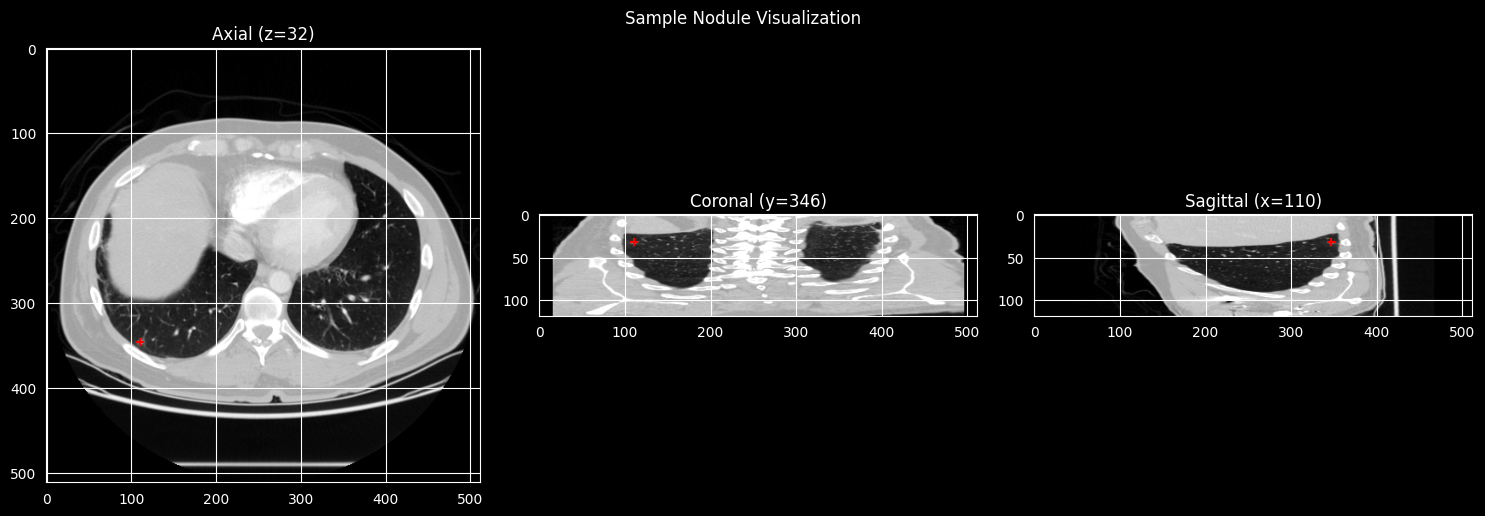

In [5]:
# Visualize a sample nodule (3 views: Axial, Coronal, Sagittal)
sample = df_subset0.iloc[0]
uid = sample['seriesuid']
path = os.path.join(SUBSET_DIR, uid + ".mhd")

ct_img, origin, spacing = load_itk(path)
ct_norm = normalize_hu(ct_img)

world_coord = np.array([sample['coordZ'], sample['coordY'], sample['coordX']])
voxel_coord = world_to_voxel(world_coord, origin, spacing)

print(f"Visualizing: {uid}")
print(f"World Coord: {world_coord}")
print(f"Voxel Coord: {voxel_coord}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
z, y, x = voxel_coord

axes[0].imshow(ct_norm[z, :, :], cmap='gray')
axes[0].scatter(x, y, c='red', s=40, marker='+')
axes[0].set_title(f'Axial (z={z})')

axes[1].imshow(ct_norm[:, y, :], cmap='gray')
axes[1].scatter(x, z, c='red', s=40, marker='+')
axes[1].set_title(f'Coronal (y={y})')

axes[2].imshow(ct_norm[:, :, x], cmap='gray')
axes[2].scatter(y, z, c='red', s=40, marker='+')
axes[2].set_title(f'Sagittal (x={x})')

plt.suptitle("Sample Nodule Visualization")
plt.tight_layout()
plt.show()

## 4. Data Generation — Extract Patches

In [6]:
if len(os.listdir(OUTPUT_DIR)) >= 10:
    print(f"Data already generated ({len(os.listdir(OUTPUT_DIR))} files). Skipping.")
else:
    print("Generating patches...")
    for idx, row in tqdm(df_subset0.iterrows(), total=len(df_subset0)):
        uid = row['seriesuid']
        path = os.path.join(SUBSET_DIR, uid + ".mhd")

        try:
            ct_img, origin, spacing = load_itk(path)
            ct_img = normalize_hu(ct_img)

            world_coord = np.array([row['coordZ'], row['coordY'], row['coordX']])
            voxel_coord = world_to_voxel(world_coord, origin, spacing)
            patch = extract_patch(ct_img, voxel_coord, PATCH_SIZE)

            # Sphere mask based on diameter
            mask = np.zeros_like(patch)
            r = max(2, int(row['diameter_mm'] / spacing[2] / 2))
            c = PATCH_SIZE // 2
            zz, yy, xx = np.ogrid[:PATCH_SIZE, :PATCH_SIZE, :PATCH_SIZE]
            mask[(zz - c)**2 + (yy - c)**2 + (xx - c)**2 <= r**2] = 1

            np.save(os.path.join(OUTPUT_DIR, f"pos_{idx}_img.npy"), patch)
            np.save(os.path.join(OUTPUT_DIR, f"pos_{idx}_mask.npy"), mask)

            rand_center = (
                np.random.randint(0, ct_img.shape[0]),
                np.random.randint(0, ct_img.shape[1]),
                np.random.randint(0, ct_img.shape[2]),
            )
            patch_neg = extract_patch(ct_img, rand_center, PATCH_SIZE)
            mask_neg = np.zeros_like(patch_neg)

            np.save(os.path.join(OUTPUT_DIR, f"neg_{idx}_img.npy"), patch_neg)
            np.save(os.path.join(OUTPUT_DIR, f"neg_{idx}_mask.npy"), mask_neg)

        except Exception as e:
            print(f"Error processing {uid}: {e}")
            continue

    print("Data generation complete.")

print(f"Total files in {OUTPUT_DIR}: {len(os.listdir(OUTPUT_DIR))}")

Data already generated (448 files). Skipping.
Total files in processed_data/train: 448


## 5. Dataset & DataLoader (with Train/Val Split)

In [7]:
class NoduleDataset(Dataset):
    def __init__(self, data_dir):
        self.img_files = sorted(glob.glob(os.path.join(data_dir, "*_img.npy")))
        self.mask_files = [f.replace("_img.npy", "_mask.npy") for f in self.img_files]

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img = np.load(self.img_files[idx])
        mask = np.load(self.mask_files[idx])
        img = np.expand_dims(img, axis=0)     # (1, D, H, W)
        mask = np.expand_dims(mask, axis=0)    # (1, D, H, W)
        return torch.from_numpy(img).float(), torch.from_numpy(mask).float()


# Create dataset and split 80/20
full_dataset = NoduleDataset(OUTPUT_DIR)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train

train_dataset, val_dataset = random_split(
    full_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total samples: {n_total}")
print(f"Train: {n_train} | Val: {n_val}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Total samples: 224
Train: 179 | Val: 45
Train batches: 90 | Val batches: 23


## 6. Model Training (with Validation Dice Tracking)

In [8]:
# Initialize model
model = BasicUNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    features=(16, 16, 32, 64, 128, 16)
).to(DEVICE)

# Loss & Optimizer
loss_fn = DiceLoss(sigmoid=True)
bce_fn = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
dice_metric = DiceMetric(include_background=True, reduction="mean")

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Training for {EPOCHS} epochs on {DEVICE}...")

BasicUNet features: (16, 16, 32, 64, 128, 16).
Model parameters: 1,438,785
Training for 3 epochs on cpu...


In [9]:
train_losses = []
val_dice_scores = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0

    progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]")
    for imgs, masks in progress:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = loss_fn(outputs, masks) + 0.5 * bce_fn(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    model.eval()
    dice_metric.reset()

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            outputs = model(imgs)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            dice_metric(preds, masks)

    val_dice = dice_metric.aggregate().item()
    val_dice_scores.append(val_dice)

    print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {avg_loss:.4f} | Val Dice: {val_dice:.4f}")

    # Save checkpoint every 3 epochs
    if (epoch + 1) % 3 == 0:
        ckpt = f"model_epoch_{epoch+1}.pth"
        torch.save(model.state_dict(), ckpt)
        print(f"  Checkpoint saved: {ckpt}")

# Save final model
torch.save(model.state_dict(), "model_final.pth")
print("Training complete. Model saved: model_final.pth")

Epoch 1/3 [Train]: 100%|██████████| 90/90 [03:05<00:00,  2.06s/it, loss=1.1225]


Epoch 1/3 — Loss: 1.1844 | Val Dice: 0.0490


Epoch 2/3 [Train]: 100%|██████████| 90/90 [03:03<00:00,  2.03s/it, loss=0.9955]


Epoch 2/3 — Loss: 1.0821 | Val Dice: 0.3430


Epoch 3/3 [Train]: 100%|██████████| 90/90 [03:04<00:00,  2.05s/it, loss=1.0284]


Epoch 3/3 — Loss: 1.0212 | Val Dice: 0.3142
  Checkpoint saved: model_epoch_3.pth
Training complete. Model saved: model_final.pth


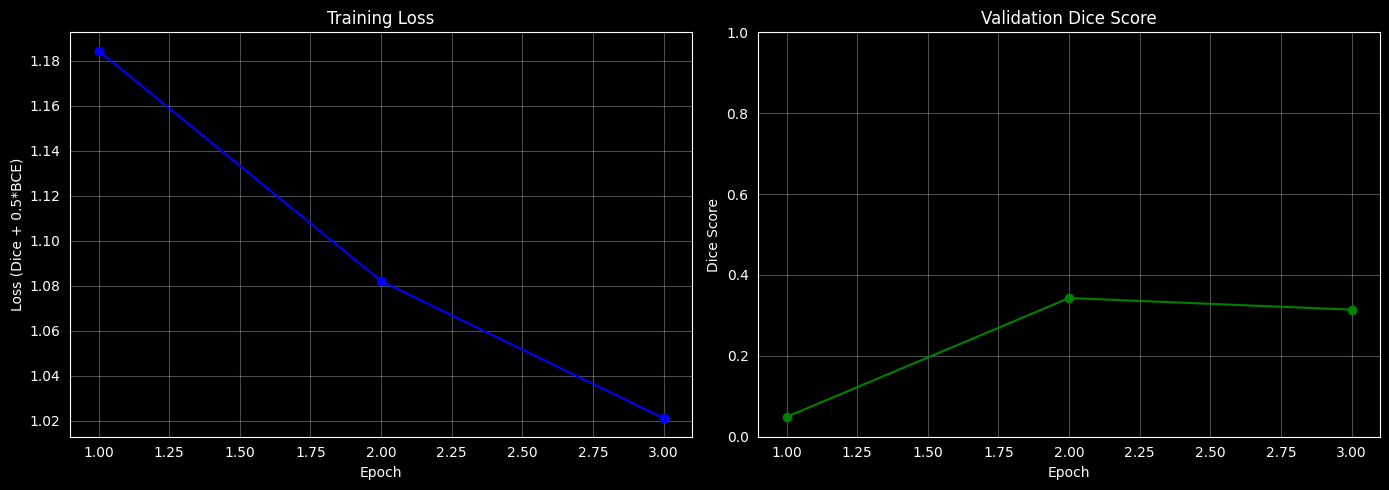

Best Val Dice: 0.3430 (Epoch 2)


In [10]:
# Plot training loss & validation Dice
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, EPOCHS+1), train_losses, 'b-o')
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss (Dice + 0.5*BCE)")
ax1.grid(True, alpha=0.3)

ax2.plot(range(1, EPOCHS+1), val_dice_scores, 'g-o')
ax2.set_title("Validation Dice Score")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Dice Score")
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100)
plt.show()
print(f"Best Val Dice: {max(val_dice_scores):.4f} (Epoch {np.argmax(val_dice_scores)+1})")

## 7. Evaluation & Inference

In [11]:
def predict_volume(model, ct_img, device=DEVICE):
    model.eval()
    input_tensor = torch.from_numpy(ct_img).float().unsqueeze(0).unsqueeze(0).to(device)

    with torch.no_grad():
        output = sliding_window_inference(
            inputs=input_tensor,
            roi_size=(32, 32, 32),
            sw_batch_size=2,
            predictor=model,
            overlap=0.25
        )
        probs = torch.sigmoid(output)
        prediction = (probs > 0.5).float().cpu().numpy()[0, 0]

    return prediction

In [12]:
# Load best model
MODEL_PATH = "model_final.pth"
if not os.path.exists(MODEL_PATH):
    # Fallback to epoch checkpoint
    MODEL_PATH = f"model_epoch_{EPOCHS}.pth"

eval_model = BasicUNet(
    spatial_dims=3, in_channels=1, out_channels=1,
    features=(16, 16, 32, 64, 128, 16)
).to(DEVICE)

if os.path.exists(MODEL_PATH):
    eval_model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    print(f"Model loaded: {MODEL_PATH}")
else:
    print(f"WARNING: {MODEL_PATH} not found. Using current model in memory.")
    eval_model = model  # use the model just trained

BasicUNet features: (16, 16, 32, 64, 128, 16).
Model loaded: model_final.pth


## 8. Metrics — Dice Score & Sensitivity

In [13]:
def compute_dice(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)
    if gt.sum() == 0 and pred.sum() == 0:
        return 1.0
    if gt.sum() == 0 or pred.sum() == 0:
        return 0.0
    intersection = np.logical_and(pred, gt).sum()
    return 2.0 * intersection / (pred.sum() + gt.sum())


def compute_sensitivity(pred_mask, gt_annotations, origin, spacing, threshold_mm=10.0):
    if len(gt_annotations) == 0:
        return 1.0

    detected = 0
    labeled_pred, n_objects = ndimage.label(pred_mask)

    for _, row in gt_annotations.iterrows():
        world_coord = np.array([row['coordZ'], row['coordY'], row['coordX']])
        voxel = world_to_voxel(world_coord, origin, spacing)
        z, y, x = voxel

        r_voxels = int(threshold_mm / spacing.min())
        z_s, z_e = max(0, z - r_voxels), min(pred_mask.shape[0], z + r_voxels)
        y_s, y_e = max(0, y - r_voxels), min(pred_mask.shape[1], y + r_voxels)
        x_s, x_e = max(0, x - r_voxels), min(pred_mask.shape[2], x + r_voxels)

        region = pred_mask[z_s:z_e, y_s:y_e, x_s:x_e]
        if region.sum() > 0:
            detected += 1

    sensitivity = detected / len(gt_annotations)
    return sensitivity

In [14]:
# Evaluate on sample CT scans
test_files = [f[:-4] for f in os.listdir(SUBSET_DIR) if f.endswith('.mhd')][:1]

all_dice = []
all_sensitivity = []

for uid in test_files:
    print(f"\nProcessing: {uid[:50]}...")
    path = os.path.join(SUBSET_DIR, uid + ".mhd")

    ct_img, origin, spacing = load_itk(path)
    ct_norm = normalize_hu(ct_img)

    # Predict
    pred_mask = predict_volume(eval_model, ct_norm)

    # Post-processing: remove small components (noise)
    labeled_mask, num_features = ndimage.label(pred_mask)
    if num_features > 0:
        # Keep only components > 10 voxels
        for i in range(1, num_features + 1):
            component = (labeled_mask == i)
            if component.sum() < 10:
                pred_mask[component] = 0

    labeled_mask, num_features = ndimage.label(pred_mask)
    print(f"  Objects detected (after cleanup): {num_features}")

    # Get ground truth annotations for this scan
    gt_ann = df_ann[df_ann['seriesuid'] == uid]
    print(f"  Ground truth nodules: {len(gt_ann)}")

    # Compute Dice on patch-level (using val set patches)
    if len(gt_ann) > 0:
        sens = compute_sensitivity(pred_mask, gt_ann, origin, spacing)
        all_sensitivity.append(sens)
        print(f"  Sensitivity: {sens:.4f} ({int(sens * len(gt_ann))}/{len(gt_ann)} nodules)")

# Compute average Dice on validation patches
print("\n" + "="*50)
print("Patch-level Dice Score (Validation Set):")
dice_metric.reset()
eval_model.eval()
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        outputs = eval_model(imgs)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        dice_metric(preds, masks)

final_dice = dice_metric.aggregate().item()
print(f"  Val Dice Score: {final_dice:.4f}")

if all_sensitivity:
    avg_sens = np.mean(all_sensitivity)
    print(f"  Avg Sensitivity: {avg_sens:.4f}")

print("="*50)


Processing: 1.3.6.1.4.1.14519.5.2.1.6279.6001.2720423025015863...


/home/hquan07/ML in Medicine/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/hquan07/ML in Medicine/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/a

  Objects detected (after cleanup): 1391
  Ground truth nodules: 1
  Sensitivity: 1.0000 (1/1 nodules)

Patch-level Dice Score (Validation Set):
  Val Dice Score: 0.3142
  Avg Sensitivity: 1.0000


## 9. Visualization — Inference Results

/home/hquan07/ML in Medicine/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:226: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = torch.cat([inputs[win_slice] for win_slice in unravel_slice]).to(sw_device)
/home/hquan07/ML in Medicine/.venv/lib/python3.12/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/a

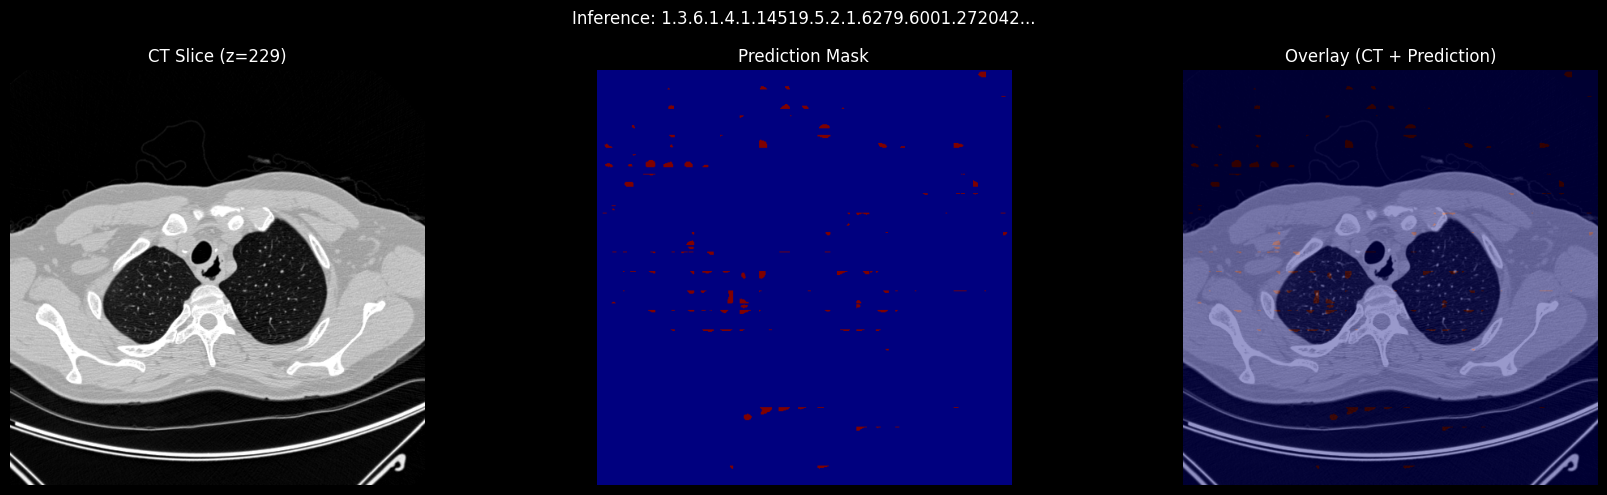


Done! All results saved.


In [15]:
# Visualize inference results for each test scan
for uid in test_files:
    path = os.path.join(SUBSET_DIR, uid + ".mhd")
    ct_img, origin, spacing = load_itk(path)
    ct_norm = normalize_hu(ct_img)

    pred_mask = predict_volume(eval_model, ct_norm)

    # Remove small noise
    labeled_mask, n = ndimage.label(pred_mask)
    for i in range(1, n + 1):
        if (labeled_mask == i).sum() < 10:
            pred_mask[labeled_mask == i] = 0

    labeled_mask, n = ndimage.label(pred_mask)

    if n > 0:
        # Find slice with most activation
        sums = np.sum(pred_mask, axis=(1, 2))
        z_slice = np.argmax(sums)

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # CT slice
        axes[0].imshow(ct_norm[z_slice], cmap='gray')
        axes[0].set_title(f"CT Slice (z={z_slice})")
        axes[0].axis('off')

        # Prediction mask
        axes[1].imshow(pred_mask[z_slice], cmap='jet')
        axes[1].set_title("Prediction Mask")
        axes[1].axis('off')

        # Overlay
        axes[2].imshow(ct_norm[z_slice], cmap='gray')
        axes[2].imshow(pred_mask[z_slice], cmap='jet', alpha=0.4)
        axes[2].set_title("Overlay (CT + Prediction)")
        axes[2].axis('off')

        plt.suptitle(f"Inference: {uid[:40]}...", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"inference_{uid[:20]}.png", dpi=100)
        plt.show()
    else:
        print(f"No nodules detected for {uid[:40]}...")

print("\nDone! All results saved.")